## 3DoF Entry Cobra w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *


from trajopt.analysis.plots_for_scitech26_pdg import *

np.random.seed(0)  # for reproducibility



setup problem and run SCP

In [2]:
# if False: 
#     example_name = "cobra_entry_3dof"
#     nominal_config  = cfg.load_configs(example_name,local=True)

#     # either generate mc variations from yamls or load existing saved mc variations
#     gen_mc_variations    = 1

#     # save mc variations to file (specificy a name for this set of mc variations as well)
#     save_mc_variations   = 0
#     mc_name = "mc1"

#     # save scenario data to file (save the scenario data struct)
#     save_scenario_data   = 0

#     # run mc analysis loop
#     # TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
#     scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name,local=True)

# if True: 
#     example_name = "cobra_entry_3dof"
#     method_name = "autotune"
#     nominal_config  = cfg.load_configs(example_name, local=True)

#     # create problem instance
#     problem = prob.Problem(nominal_config)

#     # run SCP
#     problem = scp.run_scp(problem)

#     # store scenario data struct for plotting
#     scenario_data = standalone.run_standalone_analysis(problem, method_name)

mc analysis

In [3]:
# # file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# # analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# # Can run without filename if you don't want to save LaTeX tables
# if False: 
#     analysis = stats.analyze_quality_metrics(scenario_data)

In [4]:
example_name = "lander_6dof"
method_name = "standard"
nominal_config  = cfg.load_configs(example_name)

# create problem instance
problem = prob.Problem(nominal_config)

# run SCP
problem = scp.run_scp(problem)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(problem, method_name)

scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958, none: 1.0000
Cost initial: 0.0
total number of parameters: 14628
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: lander: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
-------------------------------------------------------------------------------------------------------------------------------------

/Users/skye/virtualenvs/py3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:418: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01142.2   |   0009.5  |   0617.0   |   -3.4    |      -12.0      |    -12.0    |     -01.2   |    optimal    |   4.50   |   0.0
     02     |    00008.3   |   0008.9  |   0609.2   |   -1.6    |      -12.0      |    -12.0    |     -01.3   |    optimal    |   4.00   |   0.0
     03     |    00008.8   |   0008.2  |   0491.7   |   -0.4    |      -12.0      |    -12.0    |     -01.5   |    optimal    |   3.50   |   0.0
     04     |    00009.3   |   0010.1  |   0542.6   |   +0.0    |      -12.0      |    -12.0    |     -02.0   |    optimal    |   4.00   |   0.0
     05     |    00009.2   |   0010.0  |   0556.2   |   -0.6    |      -12.0      |    -12.0    |     -02.7   |    optimal    |   4.39   |   0.0
     06     |    00008.5   |   0010.5  |   0474.9   |   -1.4    |      -12.0      |    -12.0    |     -04.0   |    optimal    |   4.45   |   0.0
     07     |    00009.0   |   0010.7  |   0580.9   |   -2.7    |      -12.0      |    -12.0    |     -04.3   |    optimal    |   

In [5]:
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
cases = {'scenarios':['scenario1'],'methods':['standard','autotune'],'runs':list(range(1000)),'iters':list(range(1000))[1:]}
preProcess(PLTS1,problem,cases=cases);

/Users/skye/ACL/trajopt/src/trajopt/analysis/custom_functions_dan_pdg.py:52: RuntimeWarning: invalid value encountered in arccos
  return (180/np.pi)*np.arccos(1 - 2*(z[9]**2 + z[10]**2))


In [6]:
%load_ext autoreload
%autoreload 2

versions = ['standalone','sa_iters'];
figpaths = ['figs/standalone/','figs/standalone/'];

displayfigs = True;
printfigs = True; 
transparentfigs = True; 

specs = {}

specs['standalone'] = {'methods':[method_name],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':[method_name],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard',method_name],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard',method_name],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  

plotparams = {};
plotparams['problem'] = problem
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



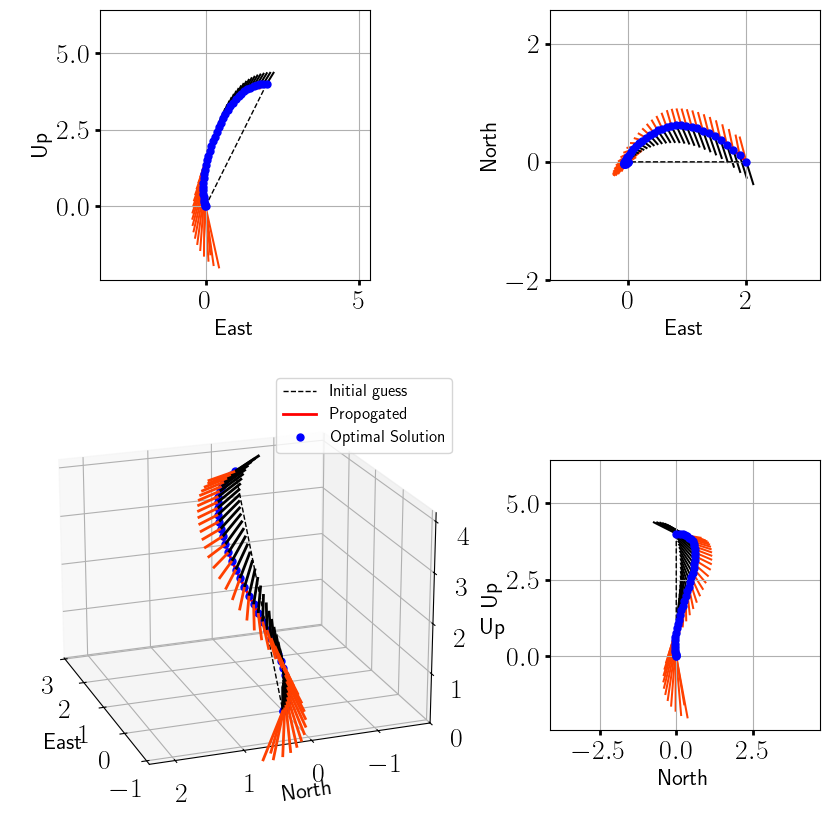

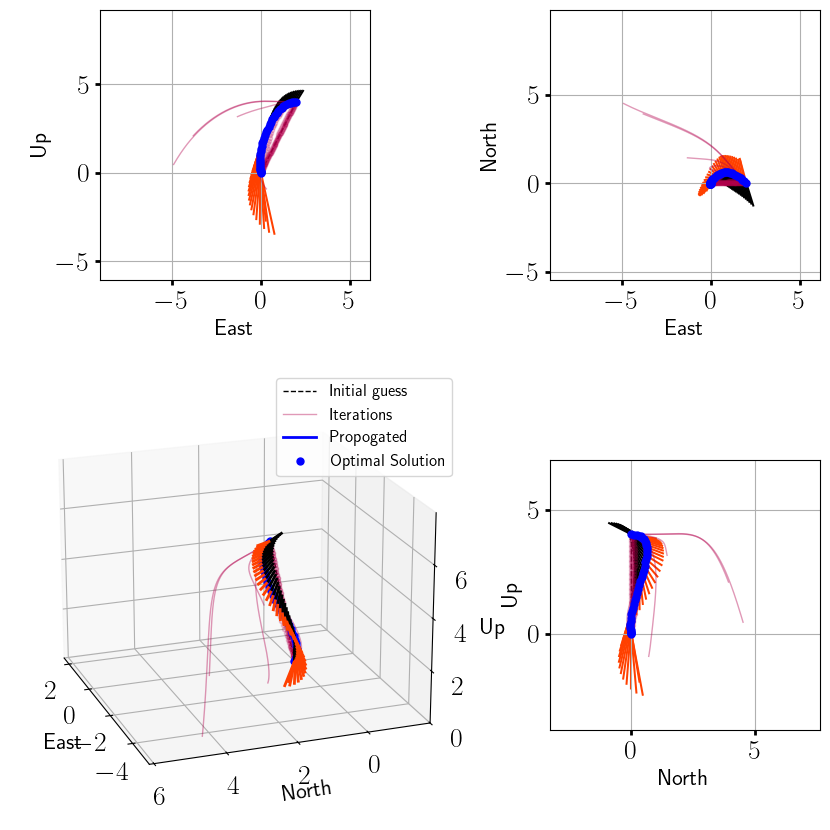

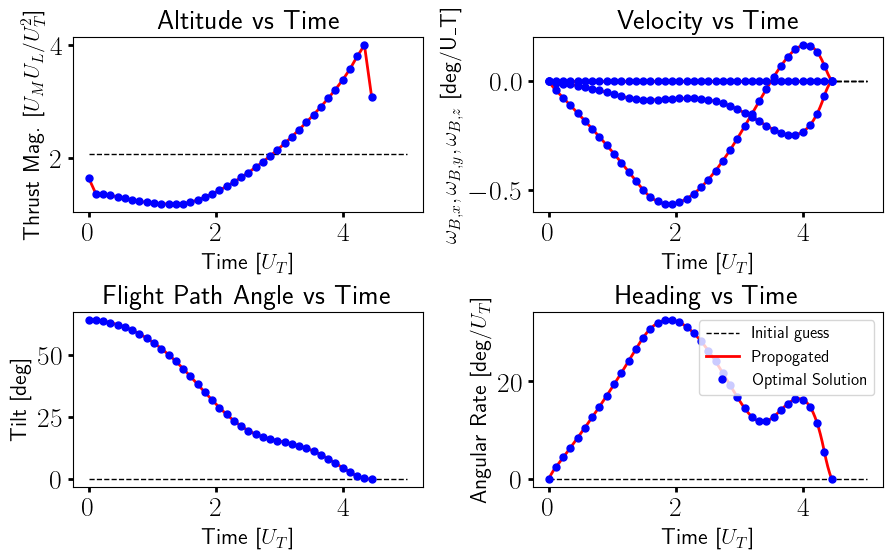

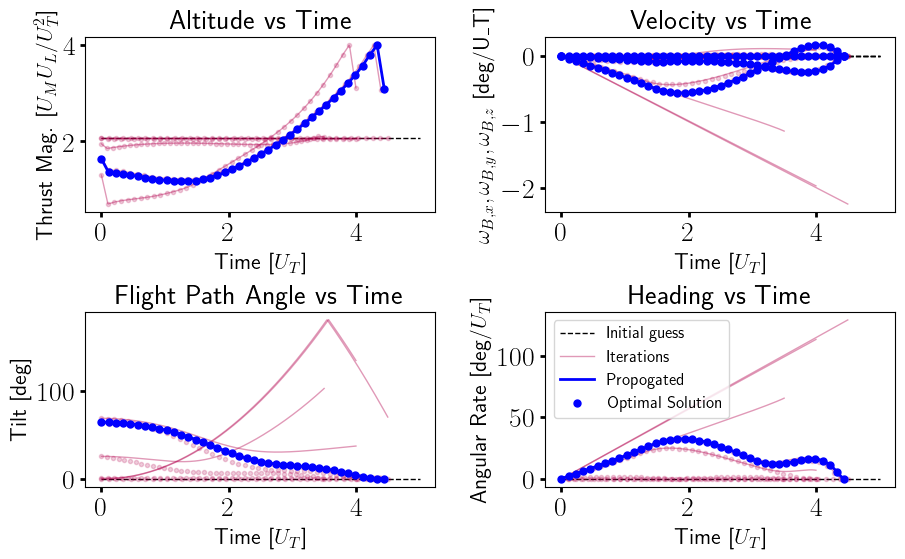

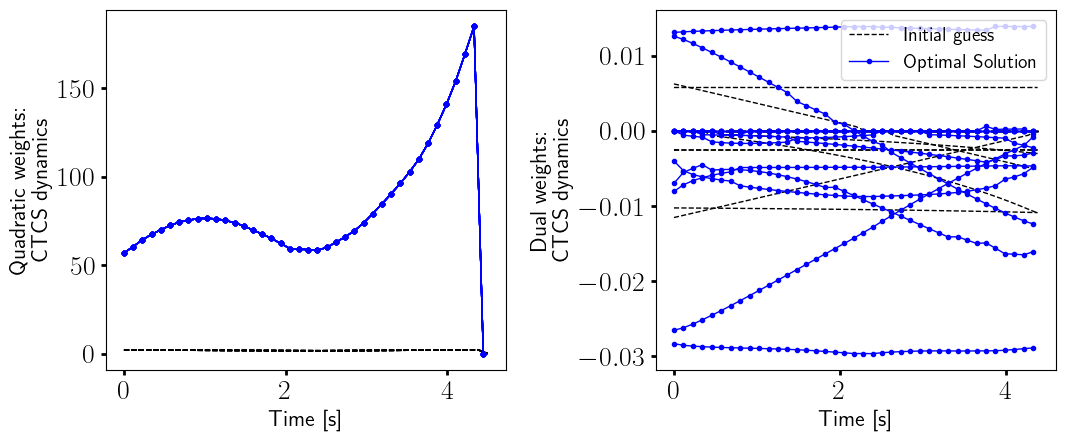

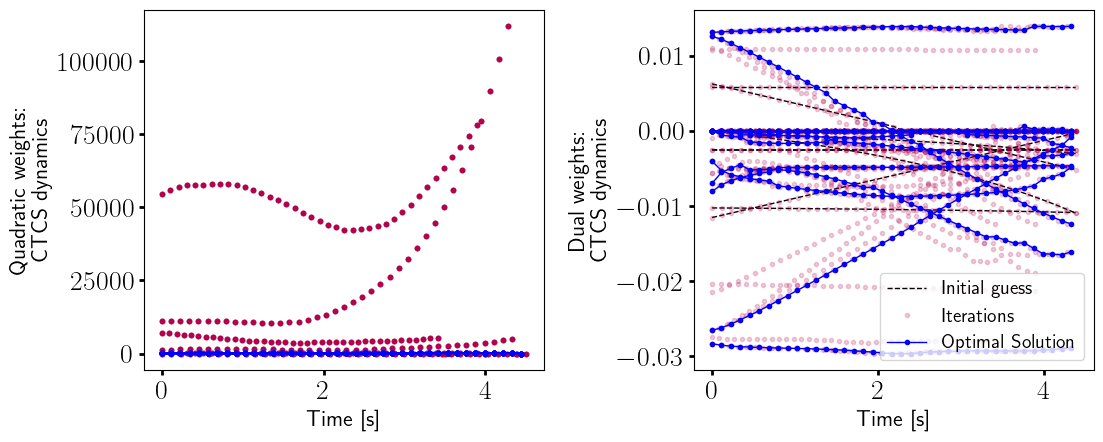

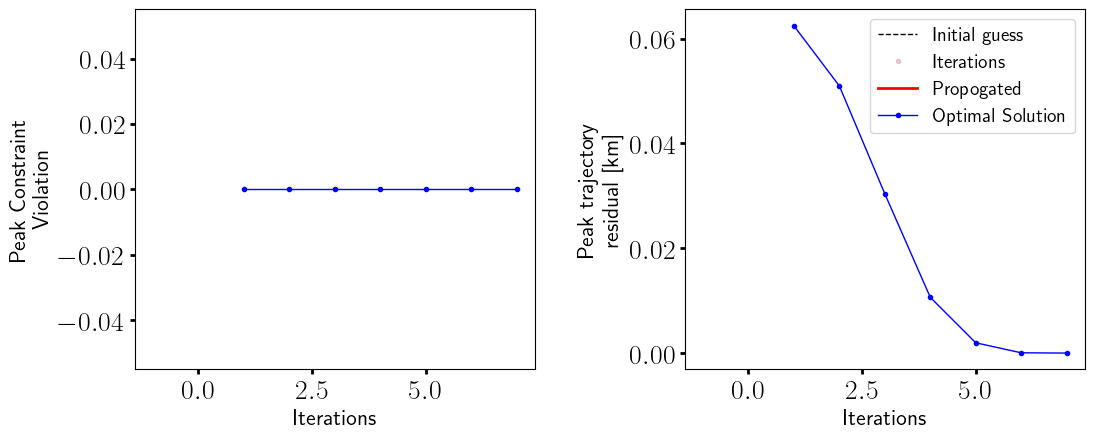

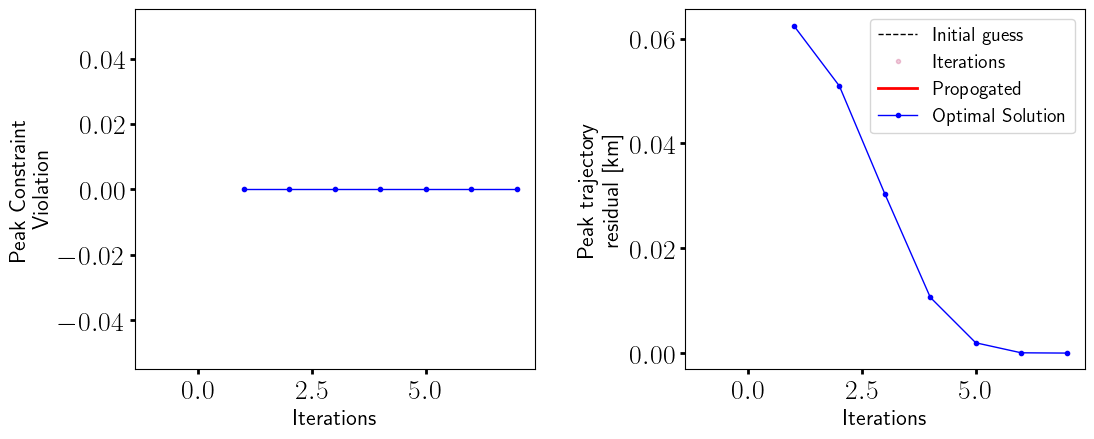

In [8]:
ALL_PLOTS = True
if ALL_PLOTS:

    newparams = {'usequiver':True,'sideviews':True,'skip':1}
    makePlotTrajs(PLTS1,ins={**plotparams,**newparams});
    
    makePlotStates(PLTS1,ins=plotparams);
    
    ### looks in 'weights' plots over time 
    # newparams = {'weights_info':['W_dyn','dual_dyn']}
    # # newparams = {'weights_info':[('W_dyn',(0)),('dual_dyn',(0,1))]}
    makePlotWghtsFlex(PLTS1,ins={**plotparams,**newparams});
    
    ### looks in 'conv_data' plots over iterations
    # newparams = {'converge_info':['chk_feas_term','chk_feas_dyn']}
    makePlotConvsFlex(PLTS1,ins={**plotparams,**newparams});
